# Проект. Яндекс Афиша
**Автор:** Топорова Е.В.  
**Дата:** 26.05.2026

К началу зимних праздников 2024 года сервис продажи билетов столкнулся с изменением спроса на различные категории мероприятий: продажи одних событий растут, а других - снижаются. Причины этих изменений неизвестны. Необходимо определить, связаны ли они с сезонностью, изменением предпочтений пользователей или особенностями аудитории, а также выявить наиболее успешные категории мероприятий, организаторов, площадки и различия в поведении пользователей мобильных и стационарных устройств.

## Цель и задачи работы
Цель: выявление инсайтов об изменении пользовательских предпочтений и популярности событий осенью 2024 года, а также проверка гипотезы о разнице в поведении пользователей с мобильными и стационарными устройствами.

Задачи:
1. Загрузить и предобработать данные.
2. Сравнить распределение заказов летом и осенью по типу мероприятий, устройств и возрастному рейтингу.
3. Проанализировать осеннюю активность пользователей.
4. Выявить топ-регионы и партнёров по заказам и выручке.
5. Проверить гипотезы.
6. Сделать выводы и рекомендации.

## Описание данных
Датасет `final_tickets_orders_df` включает информацию обо всех заказах билетов, совершённых с двух типов устройств - мобильных и стационарных. Поля датасета:
- `order_id` - уникальный идентификатор заказа.
- `user_id` - уникальный идентификатор пользователя.
- `created_dt_msk` - дата создания заказа (московское время).
- `created_ts_msk` - дата и время создания заказа (московское время).
- `event_id` - идентификатор мероприятия из таблицы events.
- `cinema_circuit` - сеть кинотеатров. Если не применимо, то здесь будет значение 'нет'.
- `age_limit` - возрастное ограничение мероприятия.
- `currency_code` - валюта оплаты, например rub для российских рублей.
- `device_type_canonical` - тип устройства, с которого был оформлен заказ, например mobile для мобильных устройств, desktop для стационарных.
- `revenue` - выручка от заказа.
- `service_name` - название билетного оператора.
- `tickets_count` - количество купленных билетов.
- `total` - общая сумма заказа.  
- `days_since_prev` - количество дней с предыдущей покупки для каждого пользователя. Если покупки не было, то данные содержат пропуск.

Второй датасет `final_tickets_events_df` содержит информацию о событиях, включая город и регион события, а также информацию о площадке проведения мероприятия. Датасет содержит такие поля:
- `event_id` - уникальный идентификатор мероприятия.
- `event_name` - название мероприятия. Аналог поля event_name_code из исходной базы данных.
- `event_type_description` - описание типа мероприятия.
- `event_type_main` — основной тип мероприятия: театральная постановка, концерт и так далее.
- `organizers` - организаторы мероприятия.
- `region_name` - название региона.
- `city_name` - название города.
- `venue_id` - уникальный идентификатор площадки.
- `venue_name` - название площадки.
- `venue_address` - адрес площадки.

Выручка от заказов представлена в двух валютах - российских рублях и казахстанских тенге. Для удобства решения было бы корректно привести данные к одной валюте, например к российским рублям. Для этого будем использовать датасет `final_tickets_tenge_df` с информацией о курсе тенге к российскому рублю за 2024 год. Значения в рублях представлено для 100 тенге. Датасет содержит такие поля:
- `nominal` - номинал (100 тенге).
- `data` - дата.
- `curs` - курс тенге к рублю.
- `cdx` - обозначение валюты (kzt).

## Содержание проекта
1. [Загрузка данных и знакомство с ними](#загрузка)
2. [Предобработка данных](#предобработка)
3. [Исследовательский анализ данных](#иад)  
    3.1 [Анализ распределения заказов по сегментам и их сезонные изменения](#сегменты-сезоны)  
    3.2. [Осенняя активность пользователей](#осень)  
    3.3. [Популярные события и партнёры](#события-партнеры)  
4. [Статистический анализ данных](#сад)
5. [Общий вывод и рекомендации](#вывод)
---

<a id="загрузка"></a>
## 1 Загрузка данных и знакомство с ними
Загрузим все необходимые для работы библиотеки.

In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats

Загрузим все данные.

In [2]:
df_orders = pd.read_csv("https://code.s3.yandex.net/datasets/final_tickets_orders_df.csv")
df_events = pd.read_csv("https://code.s3.yandex.net/datasets/final_tickets_events_df.csv")
df_tenge = pd.read_csv("https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv")

Выведем первые 5 строк каждого датасета.

In [3]:
df_orders.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


In [4]:
df_events.head()

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


In [5]:
df_tenge.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


Выведем информацию о каждом датасете.

In [6]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

Датафрейм `df_orders`:
- соотвествует заявленному описанию;
- пропуски присутствуют лишь в столбце `days_since_prev`, но им дано объяснение в описании данных;
- некоторые типы данных определены неверно:
    - `created_dt_msk` и `created_ts_msk` должны иметь тип даты (и времени),
    - у количественных признаков можно было бы снизить размерность, но датасет не очень большой, поэтому в этом нет необходимости.

In [7]:
df_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


Датафрейм `df_events`:
- соотвествует заявленному описанию,
- не содержит пропуски,
- типы данных определены верно.

In [8]:
df_tenge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


Датафрейм `df_tenge`:
- соотвествует заявленному описанию;
- не содержит пропуски;
- столбец `data` должен быть типа date, а не object.

### Промежуточный вывод
В результате знакомства с данными было выявлено, что необходимо:
- Привести `created_dt_msk` и `created_ts_msk` из `df_orders` к формату даты.
- Привести `data` из `df_tenge` к формату даты.
- Привести выручку к единой валюте (rub).

---

<a id="предобработка"></a>
## 2 Предобработка данных
Сохраним количество строк до предобработки для основной таблицы с заказами.

In [9]:
total_rows = df_orders.shape[0]

### 2.1 Типы данных
Чтобы объединить датафреймы, сначала приведем некоторые столбцы к нужному формату.

In [10]:
df_orders['created_dt_msk'] = pd.to_datetime(df_orders['created_dt_msk']).dt.normalize()
df_orders['created_ts_msk'] = pd.to_datetime(df_orders['created_ts_msk'])
df_tenge['data'] = pd.to_datetime(df_tenge['data']).dt.normalize()

Проверим преобразование.

In [11]:
df_orders.dtypes

order_id                          int64
user_id                          object
created_dt_msk           datetime64[ns]
created_ts_msk           datetime64[ns]
event_id                          int64
cinema_circuit                   object
age_limit                         int64
currency_code                    object
device_type_canonical            object
revenue                         float64
service_name                     object
tickets_count                     int64
total                           float64
days_since_prev                 float64
dtype: object

In [12]:
df_tenge.dtypes

data       datetime64[ns]
nominal             int64
curs              float64
cdx                object
dtype: object

### 2.2 Дубликаты
Перед объединением таблиц также необходимо убедиться, что ключи объединения не содержат дубликатов и данные корректны.

Проверим уникальность event_id в таблице мероприятий.

In [13]:
df_events['event_id'].duplicated().sum()

0

Проверим наличие дубликатов дат в таблице курсов валют.

In [14]:
df_tenge['data'].duplicated().sum()

0

Проверим содержимое таблицы с курсами.

In [15]:
df_tenge['cdx'].unique(), df_tenge['nominal'].unique()

(array(['kzt'], dtype=object), array([100], dtype=int64))

Таблица курсов соответствует ожидаемой структуре и не содержит лишних валют или разных номиналов.

Проверим диапазон значений курса.

In [16]:
df_tenge['curs'].describe()

count    357.000000
mean      19.755818
std        0.833798
min       17.848600
25%       19.120200
50%       19.876000
75%       20.443300
max       21.937100
Name: curs, dtype: float64

Стандартное отклонение равно 0.83, что говорит об умеренных колебаниях курса в течение года. Разница между минимальным и максимальным значениями составляет около 4 единиц, что выглядит реалистично для рыночного курса валюты.

Проверим, покрывают ли данные по курсам весь период заказов в тенге.

In [17]:
orders_min = df_orders[df_orders['currency_code'] == 'kzt']['created_dt_msk'].min()
orders_max = df_orders[df_orders['currency_code'] == 'kzt']['created_dt_msk'].max()

rates_min = df_tenge['data'].min()
rates_max = df_tenge['data'].max()

print(
    f'Период заказов в тенге: с {orders_min.date()} по {orders_max.date()}\n'
    f'Период курсов валют: с {rates_min.date()} по {rates_max.date()}'
)

Период заказов в тенге: с 2024-06-01 по 2024-10-31
Период курсов валют: с 2024-01-10 по 2024-12-31


Таблица курсов полностью покрывает период заказов.

Проверим, есть ли даты заказов в тенге без курса.

In [18]:
missing_rates = (
    df_orders[df_orders['currency_code'] == 'kzt']
    .merge(
        df_tenge[['data']],
        left_on='created_dt_msk',
        right_on='data',
        how='left'
    )
)

missing_rates['data'].isna().sum()

0

Пропусков по курсам не обнаружено.

Проверим наличие явных дубликатов в каждом датафрейме.

In [19]:
df_orders.duplicated().sum()

0

In [20]:
df_events.duplicated().sum()

0

In [21]:
df_tenge.duplicated().sum()

0

Явные дубликаты не найдены.

Теперь проверим возможные неявные дубликаты.

Первый тип - одинаковый идентификатор, но разное содержимое.

Проверим таблицу заказов.

In [22]:
df_orders['order_id'].duplicated().sum()

0

Проверим таблицу мероприятий.

In [23]:
df_events['event_id'].duplicated().sum()

0

Проверим второй тип неявных дубликатов - разные идентификаторы, но одинаковое содержание заказа.

In [24]:
duplicates = df_orders.groupby(
    ['user_id', 'event_id', 'created_ts_msk', 'tickets_count', 'revenue']
).size()

duplicates = duplicates[duplicates > 1]

print(f'Найдено дубликатов: {len(duplicates)}')

duplicates.head()

Найдено дубликатов: 41


user_id          event_id  created_ts_msk       tickets_count  revenue
06eb7897f65b433  183706    2024-08-13 16:31:07  1              69.82      2
08199117318954f  553623    2024-07-31 11:52:06  3              0.00       2
0dc525d7bacbb0d  393430    2024-07-31 13:26:11  3              1556.05    2
1f49b8de206b285  574431    2024-10-01 11:32:40  4              155.99     2
206ea45ec11d478  442183    2024-10-29 16:46:54  2              601.69     2
dtype: int64

Так как мы проверяем дубликаты по дате и времени - `created_ts_msk`, это значит, что у заказов совпадает время с точностью до секунды, и, вероятно, это результат техниченических ошибкок при записи данных. Поэтому удалим такие строки.

In [25]:
df_orders = df_orders.drop_duplicates(
    subset=['user_id', 'event_id', 'created_ts_msk', 'tickets_count', 'revenue'],
    keep='first'
)

После удаления технических дублей необходимо пересчитать количество дней между заказами, так как последовательность покупок пользователя изменилась.

Сначала отсортируем данные.

In [26]:
df_orders = df_orders.sort_values(['user_id', 'created_ts_msk'])

Пересчитаем признак days_since_prev.

In [27]:
df_orders['days_since_prev'] = (
    df_orders.groupby('user_id')['created_ts_msk']
    .diff()
    .dt.days
)

Проверим результат.

In [28]:
dupes_after = df_orders.groupby(
    ['user_id', 'event_id', 'created_ts_msk', 'tickets_count', 'revenue']
).size()

dupes_after = dupes_after[dupes_after > 1]

print(f'Осталось дубликатов: {len(dupes_after)}')

Осталось дубликатов: 0


Изучим категориальные переменные.

In [29]:
for col in ['cinema_circuit', 'age_limit', 'currency_code',
            'device_type_canonical', 'service_name']:
    print(f'{col}:\n', df_orders[col].unique())

cinema_circuit:
 ['нет' 'Другое' 'Киномакс' 'КиноСити' 'Москино' 'ЦентрФильм']
age_limit:
 [16  0 18 12  6]
currency_code:
 ['rub' 'kzt']
device_type_canonical:
 ['mobile' 'desktop']
service_name:
 ['Край билетов' 'Мой билет' 'За билетом!' 'Лови билет!'
 'Билеты без проблем' 'Облачко' 'Лучшие билеты' 'Прачечная' 'Быстробилет'
 'Дом культуры' 'Весь в билетах' 'Билеты в руки' 'Тебе билет!'
 'Show_ticket' 'Городской дом культуры' 'Яблоко' 'Билет по телефону'
 'Выступления.ру' 'Росбилет' 'Шоу начинается!' 'Мир касс' 'Восьмёрка'
 'Телебилет' 'Crazy ticket!' 'Реестр' 'Быстрый кассир' 'КарандашРУ'
 'Радио ticket' 'Дырокол' 'Вперёд!' 'Кино билет' 'Цвет и билет' 'Зе Бест!'
 'Тех билет' 'Лимоны' 'Билеты в интернете']


In [30]:
for col in ['event_type_main', 'region_name']:
    print(f'{col}:\n', df_events[col].unique())

event_type_main:
 ['театр' 'концерты' 'ёлки' 'другое' 'стендап' 'выставки' 'спорт']
region_name:
 ['Североярская область' 'Светополянский округ' 'Каменевский регион'
 'Лесодальний край' 'Медовская область' 'Широковская область'
 'Тепляковская область' 'Травяная область' 'Зоринский регион'
 'Серебринская область' 'Яблоневская область' 'Глиногорская область'
 'Речиновская область' 'Озернинский край' 'Горицветская область'
 'Солнечнореченская область' 'Травиницкий округ' 'Солнечноземская область'
 'Ключеводский округ' 'Островная область' 'Луговая область'
 'Каменноозёрный край' 'Лесостепной край' 'Зеленоградский округ'
 'Поленовский край' 'Лугоградская область' 'Синегорский регион'
 'Малиновая область' 'Речицкая область' 'Дальнеземская область'
 'Заречная область' 'Североозёрский округ' 'Дальнезорский край'
 'Малиновоярский округ' 'Сосновская область' 'Златопольский округ'
 'Ягодиновская область' 'Берестовский округ' 'Золотоключевской край'
 'Каменноярский край' 'Голубевский округ' 'Боров

Можно заметить, что неявные дубликаты в категориях отсутствуют, нормализация данных не требуется. Для столбца `cinema_circuit` значение 'нет' - это осмысленная категория (не применимо для событий вне кинотеатров), а не пропуск.

### 2.3 Объединение датафреймов
Объединим датафреймы `df_orders` и `df_events`.

In [31]:
df = df_orders.merge(df_events, on='event_id', how='left')

Присоединим также датафрейм `df_tenge` с данными по курсу валют.

In [32]:
df = df.merge(
    df_tenge[['data', 'nominal', 'curs']],
    left_on='created_dt_msk',
    right_on='data',
    how='left'
).drop('data', axis=1) # Удаляем дублирующийся столбец 'data'

### 2.4 Пропуски
Проверим наличие пропущенных значений в объединенном датафрейме.

In [33]:
(df.isna().mean() * 100).sort_values(ascending=False)

days_since_prev           7.544575
venue_address             0.081842
venue_name                0.081842
venue_id                  0.081842
city_id                   0.081842
city_name                 0.081842
region_name               0.081842
organizers                0.081842
event_type_main           0.081842
event_type_description    0.081842
event_name                0.081842
user_id                   0.000000
nominal                   0.000000
order_id                  0.000000
total                     0.000000
tickets_count             0.000000
service_name              0.000000
revenue                   0.000000
device_type_canonical     0.000000
currency_code             0.000000
age_limit                 0.000000
cinema_circuit            0.000000
event_id                  0.000000
created_ts_msk            0.000000
created_dt_msk            0.000000
curs                      0.000000
dtype: float64

`days_since_prev` содержит пропуски, как и предполагалось, оставим их без изменений.
Однако, после объединения датафреймов, пропуски появились в столбцах с информацией о мероприятиях. Они составляют всего 0.08% всех данных, поэтому их можно удалить в столбцах, которые понядобятся для работы: `event_type_main`, `region_name`, `city_name`, `venue_name`. 

In [34]:
df = df.dropna(subset=['event_type_main', 'region_name', 'city_name', 'venue_name'])

Проверим результат.

In [35]:
(df.isna().mean() * 100).sort_values(ascending=False)

days_since_prev           7.541806
user_id                   0.000000
nominal                   0.000000
venue_address             0.000000
venue_name                0.000000
venue_id                  0.000000
city_id                   0.000000
city_name                 0.000000
region_name               0.000000
organizers                0.000000
event_type_main           0.000000
event_type_description    0.000000
event_name                0.000000
order_id                  0.000000
total                     0.000000
tickets_count             0.000000
service_name              0.000000
revenue                   0.000000
device_type_canonical     0.000000
currency_code             0.000000
age_limit                 0.000000
cinema_circuit            0.000000
event_id                  0.000000
created_ts_msk            0.000000
created_dt_msk            0.000000
curs                      0.000000
dtype: float64

### 2.5 Выбросы
Проверим наличие выбросов в столбце `revenue`. Для этого выведем статистические показатели и ящики с усами по каждой валюте.

In [36]:
df.groupby('currency_code')['revenue'].describe()

,count,mean,std,min,25%,50%,75%,max
currency_code,,,,,,,,
kzt,5068.0,4995.827484,4917.039292,0.00,518.100,3698.83,7397.66,26425.86
rub,285499.0,548.032790,871.784009,-90.76,114.215,346.70,793.32,81174.54


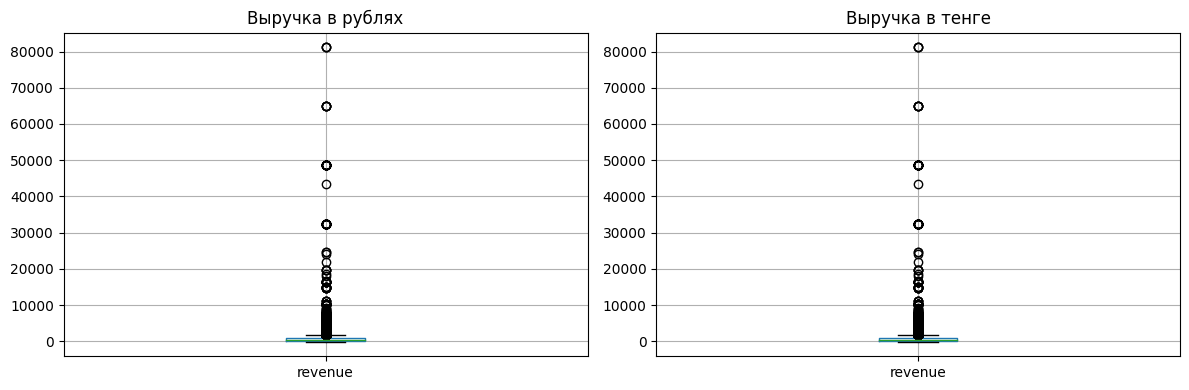

In [37]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
df[df['currency_code'] == 'rub'].boxplot(column='revenue')
plt.title('Выручка в рублях')

plt.subplot(1, 2, 2)
df[df['currency_code'] == 'rub'].boxplot(column='revenue')
plt.title('Выручка в тенге')
plt.tight_layout()
plt.show()

Судя по ящикам с усами и показателям, можно сделать следующие выводы:
1. rub
- распределение сильно скошено вправо (большинство заказов сосредоточено слева, хвост уходит вправо до 80 000 руб);
- пик приходится на маленькие суммы (0-1000 руб);
- медиана (347 руб) сильно меньше среднего (548 руб) - подтверждение правосторонней асимметрии;
- есть отрицательные значения (-90.76 руб) - вероятно, это возвраты;
- есть экстремальные выбросы до 81 174 руб (скорее всего, это B2B-заказы или ошибки).

2. kzt
- разброс значений шире (стандартное отклонение 4 917 при среднем 4 996);
- нет отрицательных значений (мин = 0);
- максимум (26 426 тенге) не выглядит таким аномальным, как в рублях.

Удалим выбросы по 99-му перцентилю (отдельно для каждой валюты).

In [38]:
rub_99 = df[df['currency_code'] == 'rub']['revenue'].quantile(0.99)
kzt_99 = df[df['currency_code'] == 'kzt']['revenue'].quantile(0.99)

df = df[
    ((df['currency_code'] == 'rub') & (df['revenue'] <= rub_99)) |
    ((df['currency_code'] == 'kzt') & (df['revenue'] <= kzt_99))
]

Проверим, сколько в данных отрицательных значений.

In [39]:
df[df['revenue'] <= 0].shape[0] / df.shape[0] * 100

2.052207034847553

Отрицательные значения составляют всего 2% данных, избавимся от них.

In [40]:
df = df[df['revenue'] >= 0]

Проверим наличие выбросов в столбце `tickets_count`. Для этого выведем статистические показатели и ящик с усами.

In [41]:
df['tickets_count'].describe()

count    287358.000000
mean          2.741051
std           1.162474
min           1.000000
25%           2.000000
50%           3.000000
75%           3.000000
max          57.000000
Name: tickets_count, dtype: float64

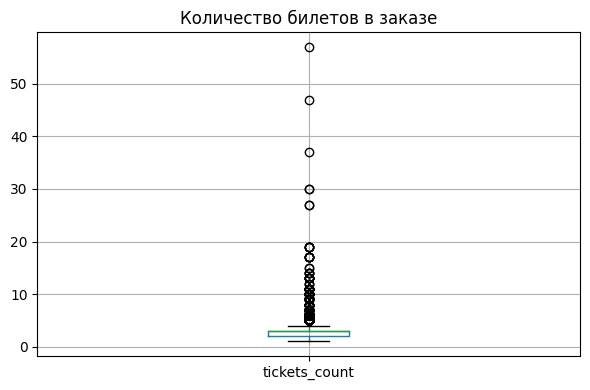

In [42]:
plt.figure(figsize=(6, 4))
df.boxplot(column='tickets_count')
plt.title('Количество билетов в заказе')
plt.tight_layout()
plt.show()

Выводы по количеству билетов:
- типичный заказ - 3 билета (75% заказов),
- максимум 57 билетов - редкий выброс (возможно, корпоративный заказ или техническая ошибка),
- в целом, в заказах бывает не более 4-5 билетов.

Удалим выбросы в количестве билетов также по 99-му перцентилю.

In [43]:
tickets_99 = df['tickets_count'].quantile(0.99)
df = df[df['tickets_count'] <= tickets_99]

### 2.6 Создание новых столбцов
Для удобства работы необходимо создать несколько столбцов:
- `revenue_rub` - выручка с заказа, приведенная к единой валюте - российскому рублю;
- `one_ticket_revenue_rub` - выручка с продажи одного билета на мероприятие;
- `month`- месяц оформления заказа;
- `season` - столбец с информацией о сезонности, включая такие категории, как: 'лето', 'осень', 'зима', 'весна'.

In [44]:
df['revenue_rub'] = df['revenue'].where(df['currency_code'] == 'rub',
                                        df['revenue'] * df['curs'] / df['nominal'])

df['one_ticket_revenue_rub'] = df['revenue_rub'] / df['tickets_count']

df['month'] = df['created_dt_msk'].dt.month

df['season'] = df['month'].map({
    1: 'зима', 2: 'зима', 3: 'весна',
    4: 'весна', 5: 'весна', 6: 'лето',
    7: 'лето', 8: 'лето', 9: 'осень',
    10: 'осень', 11: 'осень', 12: 'зима'
})

Проверим успешность конвертации валюты.

In [45]:
df[df['currency_code']=='kzt'].head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,city_id,venue_id,venue_name,venue_address,nominal,curs,revenue_rub,one_ticket_revenue_rub,month,season
73,7850214,0033403583a55ed,2024-09-17,2024-09-17 16:52:06,559919,нет,6,kzt,mobile,518.10,...,163.0,1533.0,"Клуб настольного тенниса ""Фазенда"" Инк","пер. Семашко, д. 8/7 стр. 7",100,19.0125,98.503762,24.625941,9,осень
92,8634925,0040e12d70fae81,2024-09-02,2024-09-02 19:49:14,559476,нет,6,kzt,desktop,347.18,...,163.0,1533.0,"Клуб настольного тенниса ""Фазенда"" Инк","пер. Семашко, д. 8/7 стр. 7",100,18.9330,65.731589,21.910530,9,осень
99,7625522,0054b38b2653e6e,2024-09-09,2024-09-09 18:06:04,559582,нет,6,kzt,mobile,328.77,...,163.0,1533.0,"Клуб настольного тенниса ""Фазенда"" Инк","пер. Семашко, д. 8/7 стр. 7",100,18.5991,61.148261,15.287065,9,осень
472,2229782,01370a0e9c1a7d5,2024-06-04,2024-06-04 13:17:35,533803,нет,16,kzt,mobile,3698.83,...,162.0,3407.0,"Арт-кафе ""Речка"" Лимитед","алл. Путейская, д. 548 стр. 7",100,19.9833,739.148295,369.574148,6,лето
473,2229811,01370a0e9c1a7d5,2024-06-04,2024-06-04 13:19:47,533803,нет,16,kzt,mobile,7397.66,...,162.0,3407.0,"Арт-кафе ""Речка"" Лимитед","алл. Путейская, д. 548 стр. 7",100,19.9833,1478.296591,369.574148,6,лето


Проверим, что выручка в рублях была записана без изменений.

In [46]:
df[df['currency_code']=='rub'].head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,city_id,venue_id,venue_name,venue_address,nominal,curs,revenue_rub,one_ticket_revenue_rub,month,season
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,...,213.0,3972.0,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",100,18.6972,1521.94,380.4850,8,лето
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,...,213.0,2941.0,"Музыкальная школа для детей ""Аккаунт"" Лтд","алл. Шмидта, д. 9 стр. 4",100,18.3419,289.45,144.7250,7,лето
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,...,213.0,4507.0,"Училище искусств ""Нирвана"" Инк","алл. Юбилейная, д. 5/6",100,19.6475,1258.57,314.6425,10,осень
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,...,2.0,3574.0,"Театр альтернативного искусства ""Ода"" Лимитед","алл. Есенина, д. 243 к. 3/8",100,18.5010,8.49,4.2450,7,лето
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,...,240.0,1896.0,"Театр кукол ""Огни"" Инкорпорэйтед","ш. Набережное, д. 595 стр. 8",100,19.6648,1390.41,463.4700,10,осень


### 2.7 Промежуточный вывод
Посчитаем, на сколько уменьшился датафрейм.

In [47]:
100 - df.shape[0] * 100 / total_rows

1.262166966363992

В результате предобработки данных датасет сократился на 1.25%, что приемлемо.

Были проведены следующие преобразования:
- столбцы `created_dt_msk`, `created_ts_msk` и `data` приведены к формату даты и времени;
- все 3 датафрема объединены в 1;
- удалены неявные дубликаты заказов; 
- обработаны выбросы в столбцах `revenue` и `tickets_count`;
- добавлены новые столбцы `revenue_rub`, `one_ticket_revenue_rub`, `month`, `season`.

---

<a id="иад"></a>
## 3 Исследовательский анализ данных
<a id="сегменты-сезоны"></a>
### 3.1 Анализ распределения заказов по сегментам и их сезонные изменения
Для каждого месяца найдем количество заказов и визуализируем это.

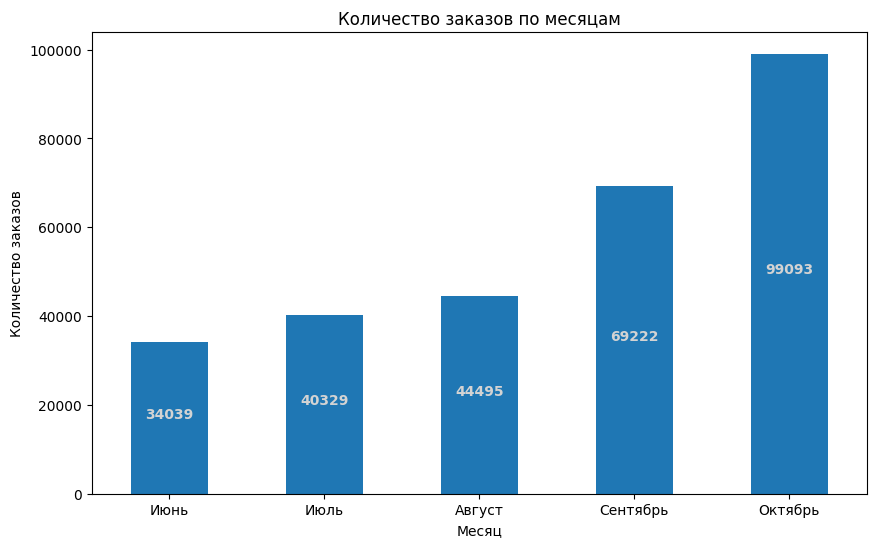

In [48]:
def add_labels(series):
    for i, v in enumerate(series):
        plt.text(i, v // 2, v, ha='center', color='lightgray', fontweight='bold')

# Заменяем индексы с цифр на названия
month_names = {6: 'Июнь', 7: 'Июль', 8: 'Август', 9: 'Сентябрь', 10: 'Октябрь'}

counts = df['month'].value_counts().sort_index()
counts.index = counts.index.map(month_names)

counts.plot(kind='bar',
            title='Количество заказов по месяцам',
            legend=False,
            ylabel='Количество заказов',
            xlabel='Месяц',
            rot=0,
            figsize=(10, 6))

add_labels(counts)
plt.show()

Как мы видим, осенью количество заказов увеличивается - с 34 тыс в июне до 99 тыс в октябре.

Теперь посмотрим на распределение заказов по сезонам более детально. Для начала в разрезе типа мероприятий.

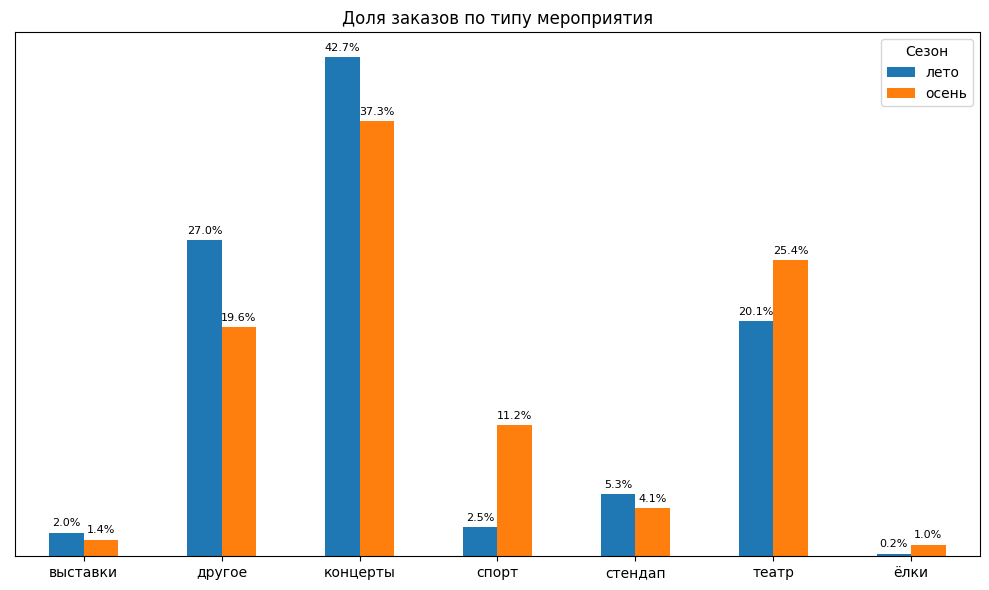

In [49]:
def plot_season_distribution(df, category_col, title, figsize=(10, 6)):
    """
    Строит график распределения заказов по сезонам для заданной категории
    
    Параметры:
    df - датафрейм
    category_col - название столбца для анализа
    title - заголовок графика
    figsize - размер графика
    """
    # Расчёт долей по сезонам
    data = (df.groupby('season')[category_col]
            .value_counts(normalize=True)
            .unstack() * 100)
    
    # Построение графика
    ax = data.T.plot(kind='bar', figsize=figsize)
    plt.title(title)
    plt.xlabel('')
    plt.legend(title='Сезон')
    plt.xticks(rotation=0)
    ax.get_yaxis().set_visible(False)
    
    # Подписываем значения
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{height:.1f}%', 
                       xy=(p.get_x() + p.get_width() / 2., height),
                       xytext=(0, 3),
                       textcoords='offset points',
                       ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plt.show()

plot_season_distribution(df, 'event_type_main', 'Доля заказов по типу мероприятия')

Летом абсолютным лидером были концерты - 42.7% всех заказов. Осенью их доля снизилась до 37.3%, хотя категория всё ещё остаётся самой популярной.

Самое заметное падение произошло у категории «другое»: с 27.0% до 19.6%. Вероятно, часть аудитории перераспределилась в более «осенние» форматы досуга.

Осенью резко вырос интерес к спорту - с 2.5% до 11.2%. Это очень сильный скачок. Возможно, это произошло из-за крупных спортивных событий в осенний период.

Также увеличилась доля театров: с 20.1% до 25.4%. Это хорошо укладывается в сезонную модель поведения - осенью люди чаще выбирают культурный и «закрытый» досуг.

Стендап и выставки немного снизились, но изменения не такие существенные:
- стендап: с 5.3% до 4.1%;
- выставки: с 2.0% до 1.4%.

Категория «ёлки» ожидаемо почти отсутствует летом и только начинает появляться осенью (повысилась с 0.2% до 1.0%), что может быть ранним стартом предновогоднего спроса.

Теперь посмотрим на распределение заказов по сезонам в разрезе типа устройств.

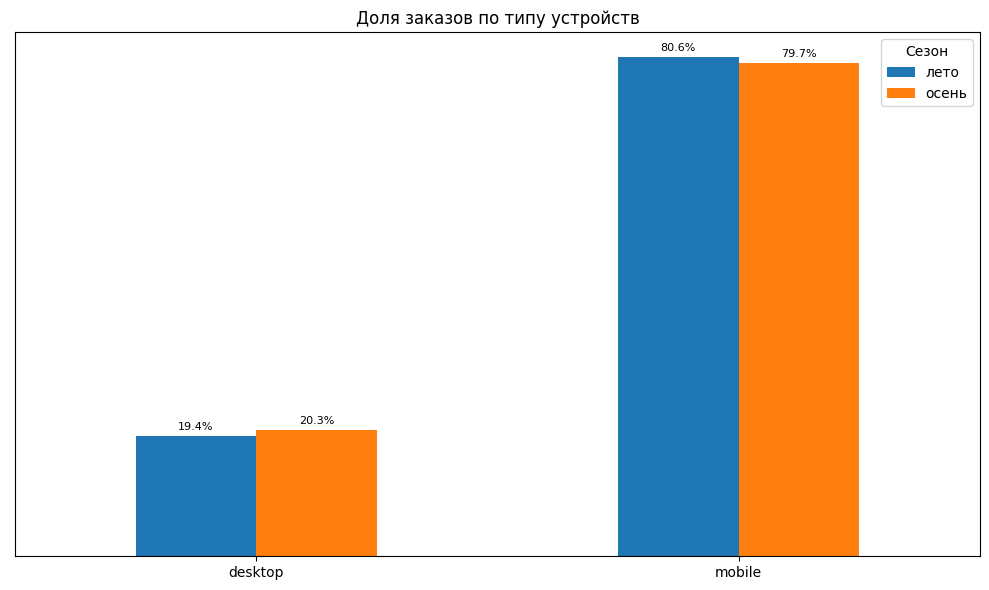

In [50]:
plot_season_distribution(df, 'device_type_canonical', 'Доля заказов по типу устройств')

Распределение заказов по типу устройства практически не изменилось между сезонами - мобильные устройства остаются доминирующим каналом оформления заказов. Доля mobile немного снизилась: с 80.6% летом до 79.7% осенью. Одновременно desktop вырос с 19.4% до 20.3%. Изменения минимальны, поэтому говорить о серьёзном изменении поведения пользователей по устройствам нельзя.

Теперь посмотрим на распределение заказов по сезонам в разрезе возрастного рейтинга.

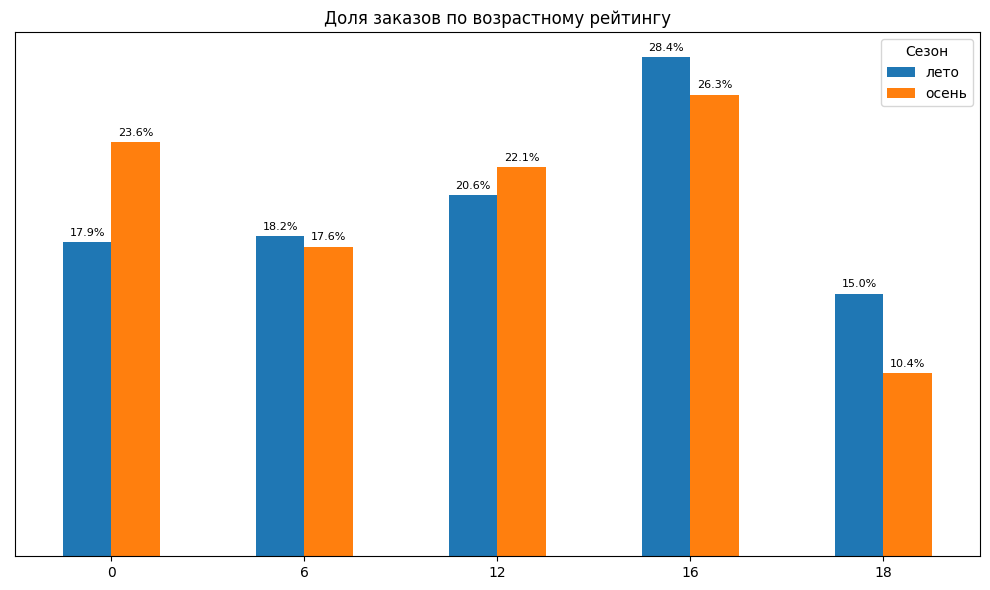

In [51]:
plot_season_distribution(df, 'age_limit', 'Доля заказов по возрастному рейтингу')

По возрастным рейтингам видно, что осенью структура спроса стала более «семейной» и менее ориентированной на взрослый контент.

Самый заметный рост показала категория 0+: с 17.9% летом до 23.6% осенью. Это может быть связано с началом учебного сезона, семейным досугом и постепенным появлением детских и праздничных мероприятий.

Также выросла доля мероприятий 12+: с 20.6% до 22.1%. Это подтверждает усиление интереса к более массовому семейному и подростковому контенту.

Категория 16+ остаётся крупнейшей в обоих сезонах: 28.4% летом и 26.3% осенью.

Самое сильное падение наблюдается у категории 18+: с 15.0% до 10.4%. Это может говорить о снижении интереса к «ночному» или взрослому развлекательному контенту осенью и переходе аудитории к более спокойным форматам досуга.

Категория 6+ практически не изменилась: c 18.2% до 17.6%.


Также посмотрим, как меняется средняя выручка за 1 билет по сезонам в разрезе мероприятий.

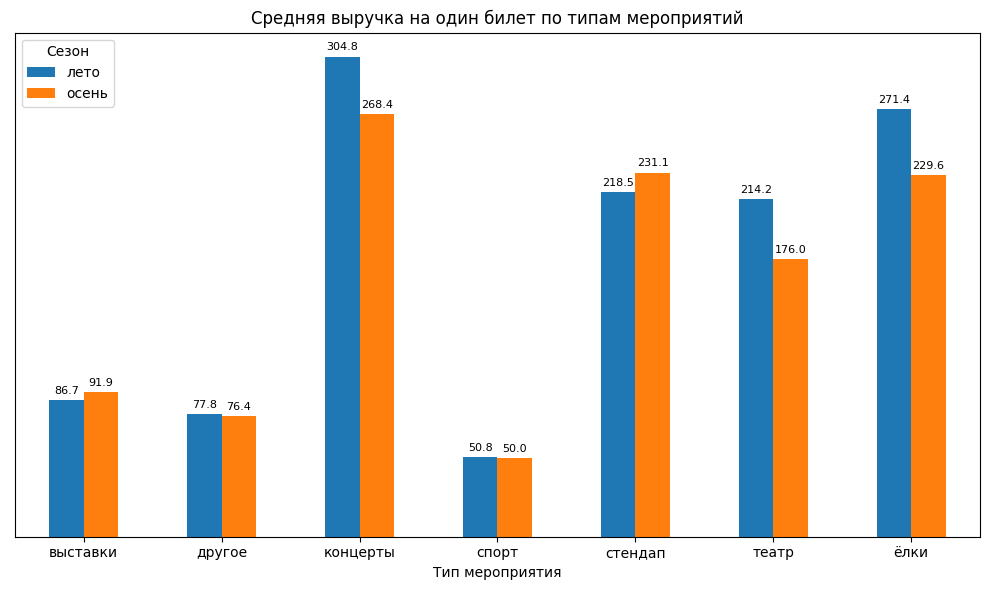

In [52]:
ticket_revenue_season = df.groupby(['season', 'event_type_main'])['one_ticket_revenue_rub'].mean().unstack()

ax = ticket_revenue_season.T.plot(kind='bar', figsize=(10, 6))
plt.title('Средняя выручка на один билет по типам мероприятий')
plt.xlabel('Тип мероприятия')
plt.legend(title='Сезон', loc='upper left')
plt.xticks(rotation=0)
ax.get_yaxis().set_visible(False)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}', 
                   xy=(p.get_x() + p.get_width() / 2., height),
                   xytext=(0, 3),
                   textcoords='offset points',
                   ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

Наиболее высокую среднюю выручку на билет как летом, так и осенью приносят концерты. Летом показатель достигает примерно 305 единиц, а осенью снижается до 268. Аналогичная ситуация наблюдается у ёлок: они остаются одной из самых прибыльных категорий, однако осенью средняя выручка также уменьшается - с 271 до 230.

В отличие от большинства других мероприятий, у стендапа осенью средняя выручка не падает, а наоборот растёт - с 218 до 231. 

Также выставки, демонстрируют небольшой рост - с 87 до 92, хотя сама категория остаётся одной из наименее прибыльных.

Театр показывает заметное снижение: с 214 до 176. Это одно из самых сильных сокращений среди всех категорий.

Категории «спорт» и «другое» практически не меняются между сезонами. Средняя выручка по ним остаётся стабильной, что может говорить о слабом влиянии сезонности на эти типы мероприятий.

<a id="осень"></a>
### 3.2 Осенняя активность пользователей
Проанализируем динамику изменений по дням для:
- общего числа заказов;
- количества активных пользователей DAU;
- среднего числа заказов на одного пользователя;
- средней стоимости одного билета.

In [53]:
# оставляем только осень 2024
autumn_orders = df[df['season'] == 'осень'].copy()
# создаём столбец с днем недели
autumn_orders['weekday'] = autumn_orders['created_dt_msk'].dt.day

# агрегируем данные по дням
daily_metrics = (
    autumn_orders.groupby(autumn_orders['created_dt_msk'])
    .agg(
        orders_count=('order_id', 'nunique'),
        dau=('user_id', 'nunique'),
        avg_ticket_price=('one_ticket_revenue_rub', 'mean')
    )
    .reset_index()
)

# среднее число заказов на пользователя
daily_metrics['orders_per_user'] = (
    daily_metrics['orders_count'] / daily_metrics['dau']
)

daily_metrics.head()

,created_dt_msk,orders_count,dau,avg_ticket_price,orders_per_user
0,2024-09-01,1327,564,200.168708,2.352837
1,2024-09-02,1376,573,190.015637,2.401396
2,2024-09-03,5094,777,80.650134,6.555985
3,2024-09-04,1759,683,179.393891,2.575403
4,2024-09-05,1937,738,190.058369,2.624661


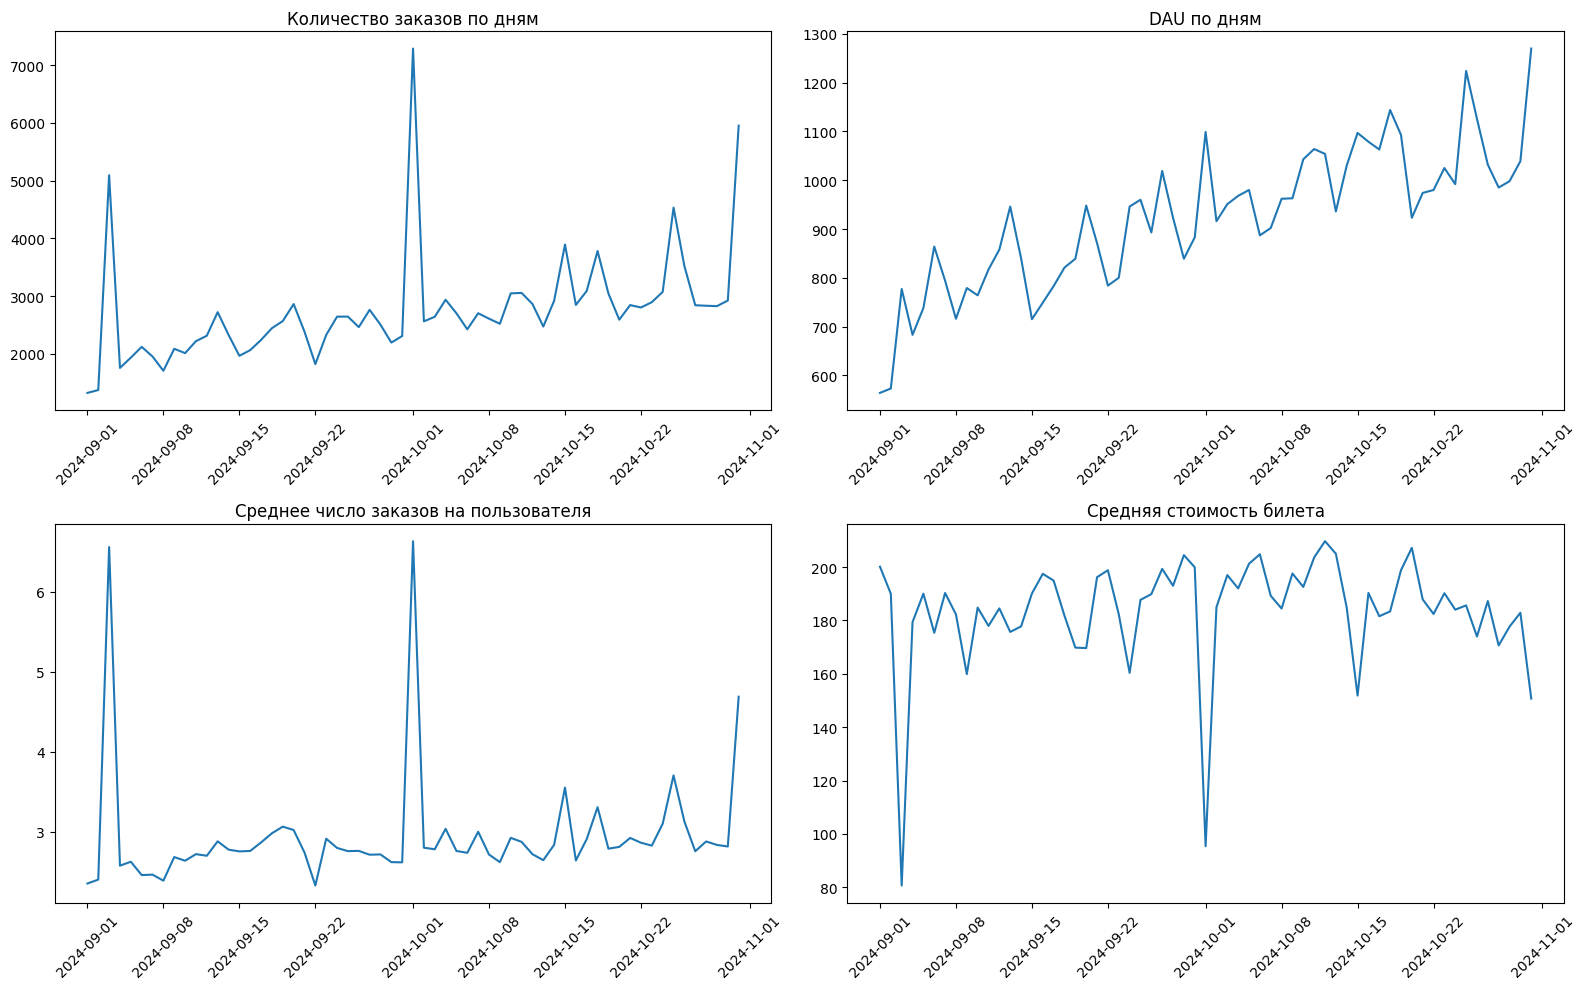

In [54]:
# визуализация динамики по дням
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# количество заказов
axes[0, 0].plot(
    daily_metrics['created_dt_msk'],
    daily_metrics['orders_count'],
)
axes[0, 0].set_title('Количество заказов по дням')
axes[0, 0].tick_params(axis='x', rotation=45) 

# DAU
axes[0, 1].plot(
    daily_metrics['created_dt_msk'],
    daily_metrics['dau']
)
axes[0, 1].set_title('DAU по дням')
axes[0, 1].tick_params(axis='x', rotation=45) 

# среднее число заказов на пользователя
axes[1, 0].plot(
    daily_metrics['created_dt_msk'],
    daily_metrics['orders_per_user']
)
axes[1, 0].set_title('Среднее число заказов на пользователя')
axes[1, 0].tick_params(axis='x', rotation=45) 

# средняя стоимость билета
axes[1, 1].plot(
    daily_metrics['created_dt_msk'],
    daily_metrics['avg_ticket_price']
)
axes[1, 1].set_title('Средняя стоимость билета')
axes[1, 1].tick_params(axis='x', rotation=45) 

plt.tight_layout()
plt.show()

Графики показывают, что в течение осени пользовательская активность постепенно растёт.

Количество заказов увеличивается от начала сентября к концу октября, при этом наблюдаются резкие всплески в отдельные дни. Особенно заметны пики в начале сентября, начале октября и в конце октября. Вероятно, они связаны с запуском продаж популярных мероприятий, акциями или массовыми событиями.

DAU также демонстрирует устойчивый восходящий тренд. Если в начале периода активных пользователей было около 550-600 в день, то к концу октября показатель превышает 1200. Это говорит о постепенном расширении аудитории и росте интереса к платформе осенью.

Среднее число заказов на одного пользователя большую часть времени остаётся стабильным - около 2-3 заказов на человека. Однако в отдельные дни наблюдаются резкие скачки выше 6 заказов. Такие аномалии могут указывать либо на групповые покупки, либо на влияние крупных мероприятий и корпоративных заказов.

Средняя стоимость билета в целом колеблется в диапазоне 170-200 рублей и не показывает ярко выраженного тренда роста или падения. При этом есть отдельные резкие просадки, например, в начале сентября и октября, что может быть связано с увеличением доли недорогих мероприятий или акционных продаж.

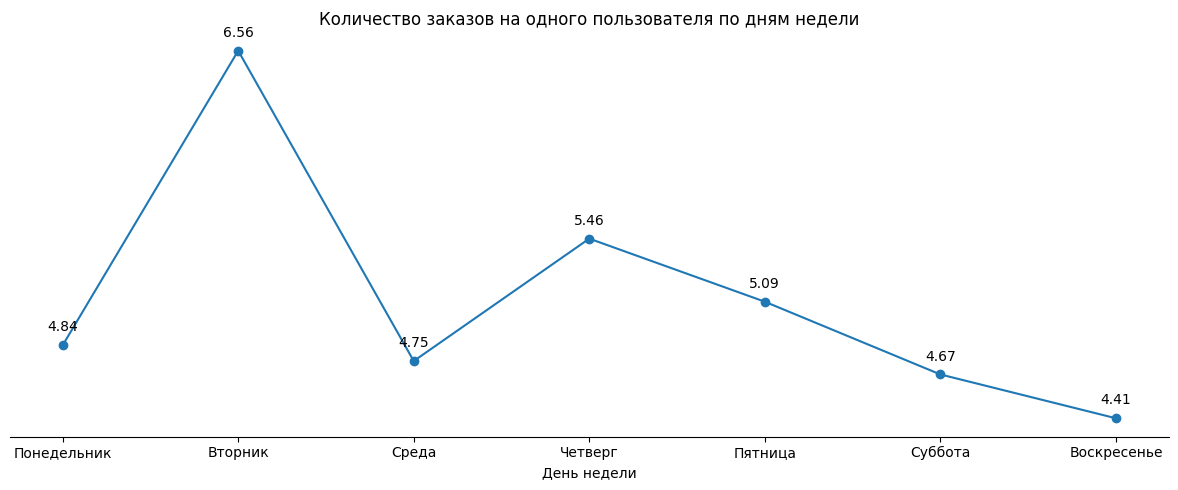

In [55]:
days_translation = {
    'Monday': 'Понедельник',
    'Tuesday': 'Вторник',
    'Wednesday': 'Среда',
    'Thursday': 'Четверг',
    'Friday': 'Пятница',
    'Saturday': 'Суббота',
    'Sunday': 'Воскресенье'
}

autumn_orders['weekday'] = autumn_orders['created_dt_msk'].dt.day_name().map(days_translation)

weekday_stats = (
    autumn_orders.groupby('weekday')
    .agg(
        orders=('order_id', 'nunique'),
        dau=('user_id', 'nunique')
    )
    .reindex(list(days_translation.values()))
)

weekday_stats['orders_per_user'] = weekday_stats['orders'] / weekday_stats['dau']

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    weekday_stats.index,
    weekday_stats['orders_per_user'],
    marker='o',
    label='Заказов на пользователя'
)

for spine in ax.spines.values():
    spine.set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.get_yaxis().set_visible(False)

plt.title('Количество заказов на одного пользователя по дням недели')
ax.set_xlabel('День недели')

for x, y in zip(weekday_stats.index, weekday_stats['orders_per_user']):
    if pd.notna(y):
        ax.annotate(f'{y:.2f}', 
                    xy=(x, y),
                    xytext=(0, 10),
                    textcoords='offset points',
                    ha='center')

plt.tight_layout()
plt.show()

По графику недельной цикличности видно, что:
- пользователи активнее всего оформляют заказы во вторник (6.56 заказов на пользователя);
- четверг и пятница - тоже выше среднего (5.46 и 5.09);
- среда - провал после мощного вторника (4.75 - падение на 28% за один день);
- выходные заметно слабее будней (-15%), причём воскресенье - абсолютный минимум;
- суббота и воскресенье показывают почти одинаковую активность (4,67 и 4,41).

<a id="события-партнеры"></a>
### 3.3 Популярные события и партнёры
Посмотрим, как события распределены по регионам. Для каждого региона посчитаем уникальное количество мероприятий и общее число заказов.

In [56]:
region_stats = df.groupby('region_name').agg(
    unique_events=('event_id', 'nunique'),
    orders=('order_id', 'nunique')
).reset_index()

region_stats['events_share'] = region_stats['unique_events'] / region_stats['unique_events'].sum()
region_stats['orders_share'] = region_stats['orders'] / region_stats['orders'].sum()

Визуализируем топ-10 регионов по мероприятиям и отдельно по заказам.

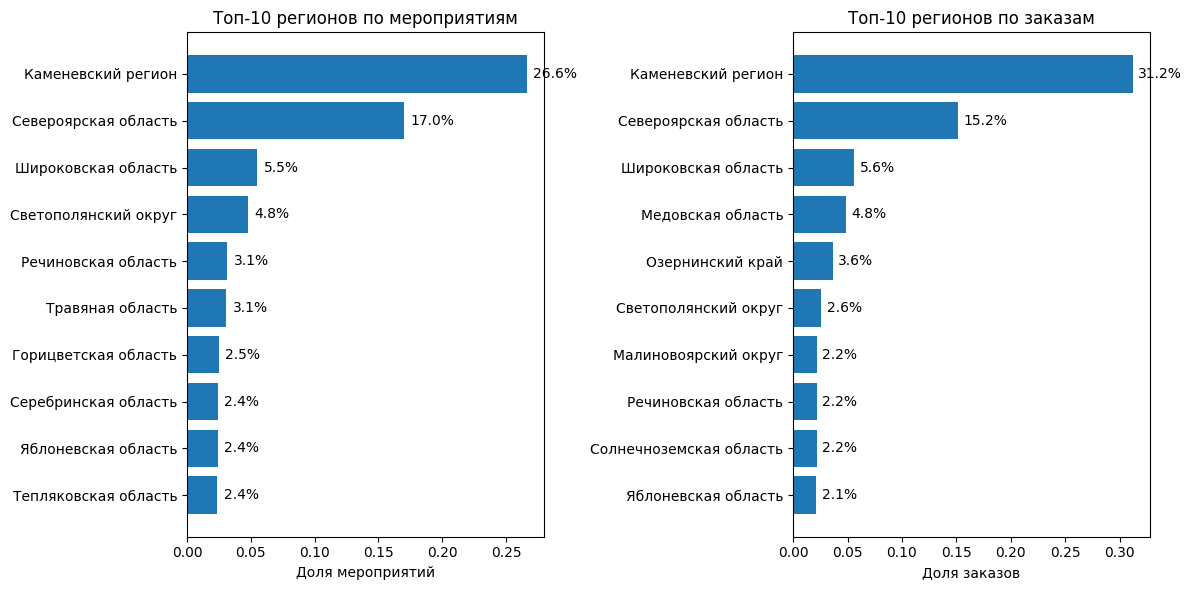

In [57]:
top_regions_events = region_stats.nlargest(10, 'events_share').copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

y_pos = np.arange(len(top_regions_events['region_name']))

ax1.barh(y_pos, top_regions_events['events_share'])
ax1.set_yticks(y_pos)
ax1.set_yticklabels(top_regions_events['region_name'])
ax1.set_xlabel('Доля мероприятий')
ax1.set_title('Топ-10 регионов по мероприятиям')
ax1.invert_yaxis()

for i, v in enumerate(top_regions_events['events_share']):
    ax1.text(v + 0.005, i, f'{v:.1%}', va='center')

top_regions_orders = region_stats.nlargest(10, 'orders_share').copy()
ax2.barh(y_pos, top_regions_orders['orders_share'])
ax2.set_yticks(y_pos)
ax2.set_yticklabels(top_regions_orders['region_name'])
ax2.set_xlabel('Доля заказов')
ax2.set_title('Топ-10 регионов по заказам')
ax2.invert_yaxis()

for i, v in enumerate(top_regions_orders['orders_share']):
    ax2.text(v + 0.005, i, f'{v:.1%}', va='center')

plt.tight_layout()
plt.show()

Посчитаем общую сумму, которая приходится на топ-10 регионов по мероприятиям и по заказам.

In [58]:
top_regions_events['events_share'].sum(), top_regions_orders['orders_share'].sum()

(0.6982139651768086, 0.7174853226918496)

И по количеству мероприятий, и по количеству заказов есть 3 явных лидера, одинаковых в обоих случаях:
1. Каменевский регион,
2. Североярская область,
3. Широковская область.

Это подтверджают и полученные суммы - 70% мероприятий и 72% заказов сосредоточены в топ-10 регионах, значит, на остальные регионы приходится намного меньше.

Посмотрим, как события распределены по партнерам. Для каждого билетного партнёра посчитаем общее число уникальных мероприятий, обработанных заказов и суммарную выручку с заказов билетов.

In [59]:
partner_stats = df.groupby('service_name').agg(
    unique_events=('event_id', 'nunique'),
    orders=('order_id', 'nunique'),
    revenue=('revenue_rub', 'sum')
).reset_index()

partner_stats['events_share'] = partner_stats['unique_events'] / partner_stats['unique_events'].sum()
partner_stats['orders_share'] = partner_stats['orders'] / partner_stats['orders'].sum()
partner_stats['revenue_share'] = partner_stats['revenue'] / partner_stats['revenue'].sum()

Визуализируем топ-10 партнеров по мероприятиям, заказам и выручке.

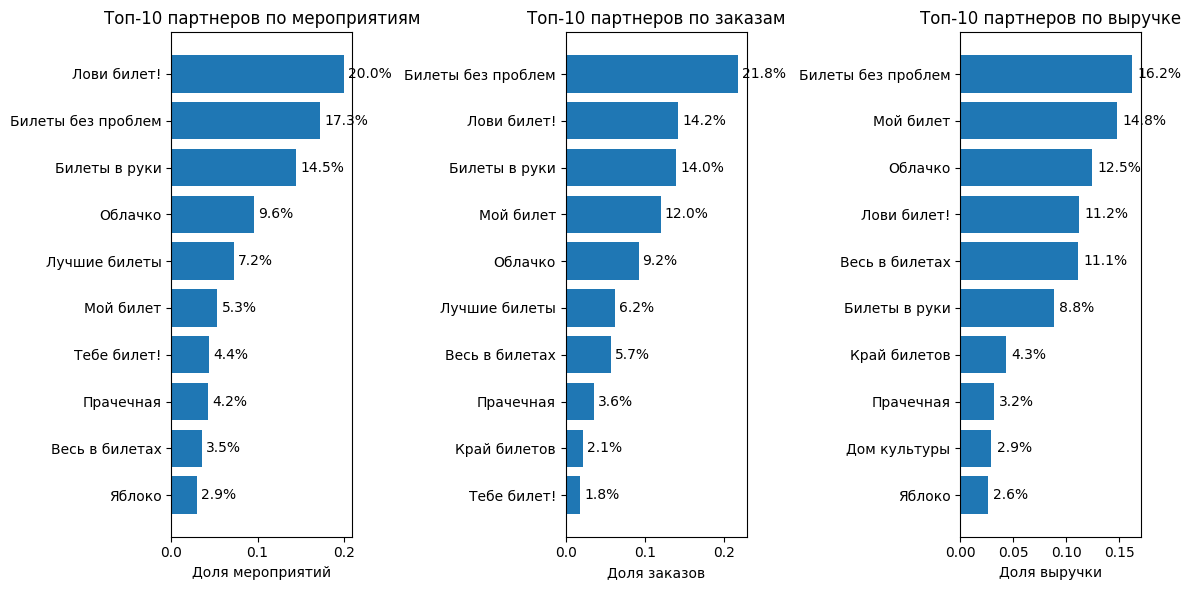

In [60]:
top_partners_events = partner_stats.nlargest(10, 'events_share').copy()

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 6))

y_pos = np.arange(len(top_partners_events['service_name']))

ax1.barh(y_pos, top_partners_events['events_share'])
ax1.set_yticks(y_pos)
ax1.set_yticklabels(top_partners_events['service_name'])
ax1.set_xlabel('Доля мероприятий')
ax1.set_title('Топ-10 партнеров по мероприятиям')
ax1.invert_yaxis()

for i, v in enumerate(top_partners_events['events_share']):
    ax1.text(v + 0.005, i, f'{v:.1%}', va='center')

top_partners_orders = partner_stats.nlargest(10, 'orders_share').copy()
ax2.barh(y_pos, top_partners_orders['orders_share'])
ax2.set_yticks(y_pos)
ax2.set_yticklabels(top_partners_orders['service_name'])
ax2.set_xlabel('Доля заказов')
ax2.set_title('Топ-10 партнеров по заказам')
ax2.invert_yaxis()

for i, v in enumerate(top_partners_orders['orders_share']):
    ax2.text(v + 0.005, i, f'{v:.1%}', va='center')

top_partners_revenue = partner_stats.nlargest(10, 'revenue_share').copy()
ax3.barh(y_pos, top_partners_revenue['revenue_share'])
ax3.set_yticks(y_pos)
ax3.set_yticklabels(top_partners_revenue['service_name'])
ax3.set_xlabel('Доля выручки')
ax3.set_title('Топ-10 партнеров по выручке')
ax3.invert_yaxis()

for i, v in enumerate(top_partners_revenue['revenue_share']):
    ax3.text(v + 0.005, i, f'{v:.1%}', va='center')

plt.tight_layout()
plt.show()

Посчитаем общую сумму, которая приходится на топ-10 партнеров по мероприятиям, заказам и выручке.

In [61]:
top_partners_events['events_share'].sum(), top_partners_orders['orders_share'].sum(), top_partners_revenue['revenue_share'].sum()

(0.8894693541752366, 0.9050031687664096, 0.8757819965320364)

Самые активные партнеры:
1. «Лови билет!»,
2. «Билеты без проблем»,
3. «Билеты в руки».

«Билеты без проблем» также первый по заказам и выручке.

«Лови билет!» входит в топ-4 по заказам и выручке.

«Билеты в руки» также присутствует во всех трех категориях, но ниже, чем «Лови билет!».

По сумме топ-10 партнеров составляют 89% мероприятий, 91% заказов и 88% выручки. Следовательно, среди них наблюдается еще больший перекос, чем по регионам.

---
<a id="сад"></a>
## 4 Статистический анализ данных

Коллеги из продуктового отдела хотят отдельно проверить несколько гипотез относительно активности пользователей мобильных и стационарных устройств.

### 4.1 Гипотеза №1


Изучим данные для первой гипотезы, которая звучит так: среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств.


Сначала проверим ситауцию, когда пользователи используют оба устройства, и посмотрим, сколько таких случаев в данных.

In [62]:
devices_per_user = (
    autumn_orders.groupby('user_id')['device_type_canonical']
    .nunique()
)

devices_per_user.value_counts()

1    12549
2     3248
Name: device_type_canonical, dtype: int64

Результат показал, что 12 549 пользователей использовали только один тип устройства, тогда как 3 248 пользователей оформляли заказы как с мобильных, так и со стационарных устройств.

Поскольку один и тот же пользователь может совершать заказы с обоих типов устройств, наблюдения являются зависимыми. Поэтому корректнее рассматривать не две независимые выборки, а разность числа заказов внутри одного пользователя. Таким образом, задача сводится к анализу распределения попарных разностей.

Для каждого пользователя считаем число заказов с каждого устройства.

In [63]:
user_device_orders = (
    autumn_orders
    .pivot_table(
        index='user_id',
        columns='device_type_canonical',
        values='order_id',
        aggfunc='nunique',
        fill_value=0
    )
)

user_device_orders.head()

device_type_canonical,desktop,mobile
user_id,,
0005ca5e93f2cf4,0,1
000898990054619,0,2
000a55a418c128c,0,2
001e7037d013f0f,0,2
00245c702bc343e,0,2


Теперь для каждого пользователя есть две связанные величины. Считаем разность.

In [64]:
user_device_orders['diff'] = (
    user_device_orders['mobile']
    - user_device_orders['desktop']
)

Посмотрим описательные статистики.

In [65]:
user_device_orders['diff'].describe()

count    15797.000000
mean         6.319238
std         47.340807
min       -246.000000
25%          1.000000
50%          1.000000
75%          4.000000
max       2835.000000
Name: diff, dtype: float64

Распределение имеет выраженную правостороннюю асимметрию и хвосты: наблюдаются пользователи с экстремально большим числом заказов с одного из устройств (до 2835 заказов разницы), а также пользователи с обратным перекосом (до -246).

При этом медианное значение разности составляет 1 заказ, что говорит о том, что для большинства пользователей различия между устройствами минимальны.

Существенное расхождение между средним (6.32) и медианой (1) указывает на сильное влияние выбросов и ограниченную интерпретируемость среднего как характеристики “типичного” пользователя.

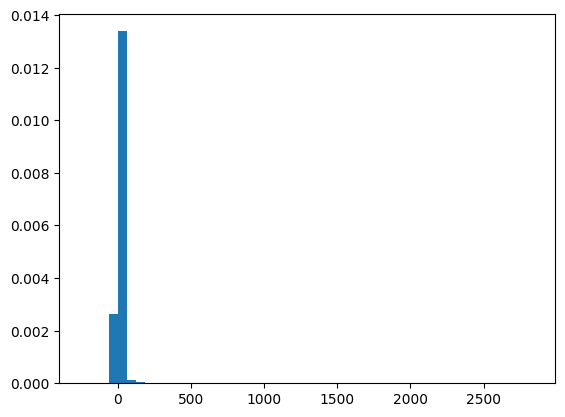

In [66]:
plt.hist(
    user_device_orders['diff'],
    bins=50,
    density=True
)
plt.show()

Гистограмма подтверждает, что распределение сильно скошено вправо, а также присутствует хвост.

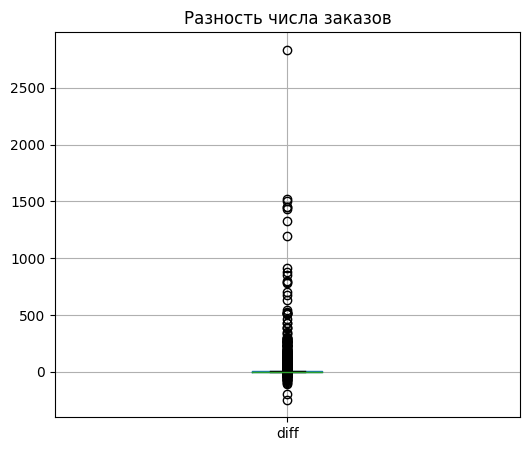

In [67]:
plt.figure(figsize=(6, 5))
user_device_orders.boxplot(column='diff')
plt.title('Разность числа заказов')
plt.show()

Используем t-test для парных выборок, так как:
- наблюдения зависимы (один пользователь, два значения),
- анализируется разность внутри пользователя,
- выборка большая (почти 16 тыс.),
- распределение разностей асимметрично, но не требует строгой нормальности при большом количестве.

Для применения t-test для парных выборок ключевым предположением является близость распределения разностей к нормальному распределению и отсутствие экстремальных выбросов. Проверка распределения разностей показала наличие выраженной асимметрии и значительных выбросов, что формально нарушает предпосылки критерия Стьюдента. Однако размер выборки (около 16 000 пользователей) является достаточно большим, что делает t-test устойчивым к умеренным отклонениям от нормальности благодаря центральной предельной теореме.

Дополнительно можно использовать непараметрический критерий Вилкоксона как проверку устойчивости результата.

Сформулируем нулевую и альтернативную гипотезы:
- Нулевая гипотеза (Н0): Среднее число заказов с мобильного устройства не больше, чем с десктопа.
- Альтернативная гипотеза (Н1): Среднее число заказов с мобильного устройства больше, чем с десктопа.

In [68]:
stat, p_value = stats.ttest_rel(
    user_device_orders['mobile'],
    user_device_orders['desktop'],
    alternative='greater'
)

alpha = 0.05
if p_value < alpha:
    print(f"p_value = {p_value:.2e}. Отвергаем H0: среднее число заказов с мобильного устройства статистически значимо выше, чем с десктопного.")
else:
    print(f"p_value = {p_value:.2e}. Не отвергаем H0: статистически значимых различий в среднем числе заказов между устройствами не обнаружено.")

p_value = 6.25e-63. Отвергаем H0: среднее число заказов с мобильного устройства статистически значимо выше, чем с десктопного.


In [69]:
stat_w, p_value_w = stats.wilcoxon(
    user_device_orders['mobile'],
    user_device_orders['desktop'],
    alternative='greater'
)

alpha = 0.05
if p_value_w < alpha:
    print(f"Wilcoxon p_value = {p_value_w:.4e}. Отвергаем H0: среднее число заказов с мобильного устройства статистически значимо выше, чем с десктопного.")
else:
    print(f"Wilcoxon p_value = {p_value_w:.4e}. Не отвергаем H0: статистически значимых различий в среднем числе заказов между устройствами не обнаружено.")

Wilcoxon p_value = 0.0000e+00. Отвергаем H0: среднее число заказов с мобильного устройства статистически значимо выше, чем с десктопного.


Оба критерия - t-test и Wilcoxon - показывают статистически значимое различие между группами. Это позволяет сделать вывод о том, что результат является устойчивым к выбору метода анализа и не обусловлен исключительно влиянием выбросов или формы распределения.

Однако дополнительный анализ распределения разностей показывает, что эффект формируется неравномерно: основная масса пользователей имеет небольшую разницу между устройствами, а наблюдаемое смещение создаётся небольшой группой высокоактивных пользователей с экстремальным числом заказов.

Это может означать, что:
- мобильное приложение стимулирует более частые покупки у небольшой группы активных пользователей,
- либо существует сегмент пользователей, которые преимущественно используют mobile,
- средний эффект не отражает поведение большинства пользователей.


### 4.2 Гипотеза №2
Теперь изучим данные для второй гипотезы, которая звучит так: среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств.

Сначала необходимо сформировать независимые группы пользователей. Один пользователь может совершать заказы как с мобильного устройства, так и со стационарного, поэтому разделение данных только по типу устройства приводит к пересечению пользователей между выборками. Чтобы обеспечить независимость наблюдений, каждого пользователя отнесём только к одной группе - по устройству, с которого он совершил большинство заказов в рассматриваемом периоде.

In [70]:
device_counts = (
    autumn_orders
    .groupby(['user_id', 'device_type_canonical'])
    .size()
    .unstack(fill_value=0)
)

device_counts['main_device'] = np.where(
    device_counts['mobile'] >= device_counts['desktop'],
    'mobile',
    'desktop'
)

main_device = (
    device_counts['main_device']
    .reset_index()
)

Важно помнить, что столбец `days_since_prev` содержит пропуски, которые характеризуют первые заказы пользователей. Их нужно исключить при анализе времени между заказами, так как в таких случаях интервала между заказами ещё не было, и они нас не интересуют.

In [71]:
user_intervals = (
    autumn_orders
    .dropna(subset=['days_since_prev'])
)

Рассчитаем для каждого пользователя средний интервал между заказами и присоединим информацию о его основной группе устройств.

In [72]:
user_intervals = (
    user_intervals
    .groupby('user_id')['days_since_prev']
    .mean()
    .reset_index(name='mean_days_between_orders')
    .merge(main_device, on='user_id')
)

Выведем описательные статистики.

In [73]:
user_intervals.groupby('main_device')['mean_days_between_orders'].describe()

,count,mean,std,min,25%,50%,75%,max
main_device,,,,,,,,
desktop,1391.0,23.467003,31.392645,0.0,1.0,10.000000,32.666667,146.0
mobile,9797.0,20.529328,27.160196,0.0,2.0,9.666667,27.666667,148.0


По статистикам можно сделать следующие выводы:
- После формирования независимых групп пользователей средний интервал между заказами оказался выше у пользователей, преимущественно использующих десктопные устройства (23.5 дня против 20.5 дня у мобильных пользователей).
- Обе группы имеют выраженную правостороннюю асимметрию (mean > median), что говорит о наличии пользователей с большими интервалами между заказами и длинным хвостом распределения.
- Максимальные значения близки (146–148 дней), что говорит о наличии пользователей с длительными перерывами в обеих группах.

Используем нормализованные распределения, так как размеры групп различаются.

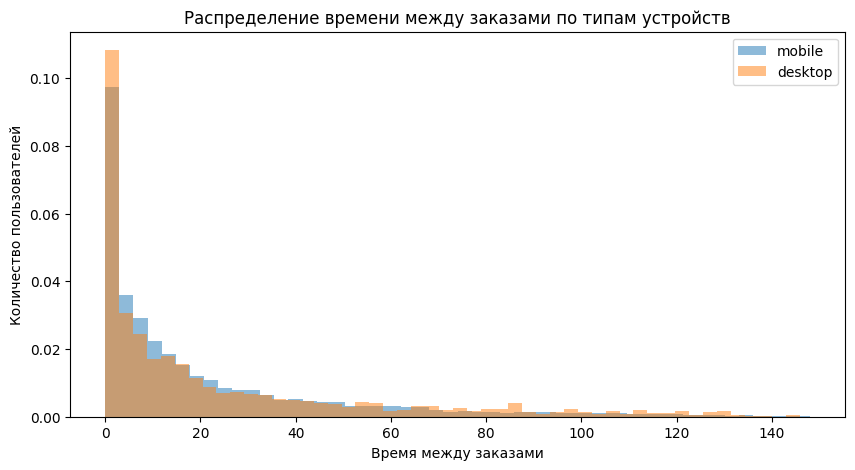

In [74]:
mobile_time = user_intervals[
    user_intervals['main_device'] == 'mobile'
]['mean_days_between_orders']

desktop_time = user_intervals[
    user_intervals['main_device'] == 'desktop'
]['mean_days_between_orders']

plt.figure(figsize=(10, 5))

plt.hist(mobile_time, bins=50, alpha=0.5, density=True, label='mobile')
plt.hist(desktop_time, bins=50, alpha=0.5, density=True, label='desktop')

plt.xlabel('Время между заказами')
plt.ylabel('Количество пользователей')
plt.title('Распределение времени между заказами по типам устройств')
plt.legend()

plt.show()

Гистограммы подтверждают, что оба распределения сильно скошены вправо, а также присутствуют длинные хвосты.

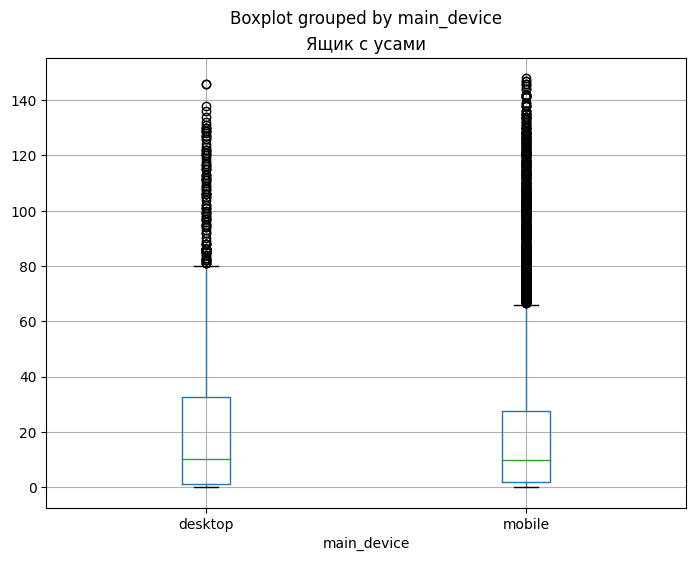

In [75]:
user_intervals.boxplot(column='mean_days_between_orders', by='main_device', figsize=(8, 6))
plt.title('Ящик с усами')
plt.show()

Ящик с усами показывает наличие выбросов.

Анализ показывает:
- распределения не являются нормальными,
- присутствуют выбросы и длинные хвосты,
- размеры выборок различаются.

Поскольку сравниваемые группы пользователей являются независимыми, а распределения содержат выбросы и обладают выраженной асимметрией, для проверки гипотезы используем непараметрический критерий Манна–Уитни, который менее чувствителен к отклонениям от нормальности и экстремальным значениям.

Сформулируем нулевую и альтернативную гипотезы:
- Нулевая гипотеза (Н0): распределение среднего времени между заказами у пользователей, преимущественно использующих мобильные устройства, не смещено в сторону больших значений по сравнению с пользователями, преимущественно использующими стационарные устройства.
- Альтернативная гипотеза (Н1): распределение среднего времени между заказами у пользователей, преимущественно использующих мобильные устройства, смещено в сторону больших значений по сравнению с пользователями, преимущественно использующими стационарные устройства.

In [76]:
stat, p_value = stats.mannwhitneyu(
    mobile_time, 
    desktop_time, 
    alternative='greater'
)

alpha = 0.05
if p_value < alpha:
    print(
        f"p_value = {p_value:.2e}. Отвергаем H0: распределение времени между заказами у пользователей, преимущественно использующих мобильные устройства, смещено в сторону больших значений."
    )
else:
    print(
        f"p_value = {p_value:.2e}. Не отвергаем H0: статистически значимых оснований утверждать, что время между заказами у пользователей, преимущественно использующих мобильные устройства, больше, чем у пользователей, преимущественно использующих стационарные устройства, не обнаружено."
    )

p_value = 4.49e-01. Не отвергаем H0: статистически значимых оснований утверждать, что время между заказами у пользователей, преимущественно использующих мобильные устройства, больше, чем у пользователей, преимущественно использующих стационарные устройства, не обнаружено.


Полученные данные не позволяют сделать вывод о том, что пользователи, преимущественно использующие мобильные устройства, имеют большее время между заказами по сравнению с пользователями, преимущественно использующими стационарные устройства.

Таким образом, статистически значимых различий в распределении среднего времени между заказами между исследуемыми группами обнаружено не было.


### 4.3 Промежуточный вывод

Результаты анализа показали, что пользователи чаще оформляют заказы через мобильные устройства, чем через стационарные.

При этом статистически значимых различий во времени между заказами между пользователями, преимущественно использующими мобильные или стационарные устройства, обнаружено не было.

Таким образом, мобильные устройства являются более популярным каналом оформления заказов, однако полученные результаты не позволяют утверждать, что выбор основного устройства связан с различиями в регулярности совершения покупок.

---
<a id="вывод"></a>
## 5 Общий вывод и рекомендации
### 5.1 Вывод
В ходе исследования были проанализированы данные сервиса Яндекс Афиша за период с июня по октябрь 2024 года. После объединения и предобработки датасетов было удалено всего 1.3% данных, что позволяет считать итоговую выборку репрезентативной для анализа.

Платформа осенью 2024 выросла по масштабу:
- заказов стало почти в три раза больше - с 34 тыс. в июне до 99 тыс. в октябре;
- ежедневная аудитория осенью поднялась с 550-600 активных пользователей в начале сентября до более 1200 к концу октября.

Но важнее другое - изменился сам спрос. Платформа стала не просто больше, а другой по составу интересов:
- Пользователи по-прежнему чаще всего покупают концерты (42,7% летом, 37,3% осенью), однако осенью сильнее «подтянулись» спорт (2,5% до 11,2%) и театр (20,1% до 25,4%), а доля «другое» снизилась с 27,0% до 19,6%.
- Структура по возрасту сместилась в сторону семейного контента: Доля мероприятий 0+ выросла с 17.9% до 23.6%, а доля 12+ - с 20.6% до 22.1%. Одновременно доля мероприятий 18+ снизилась с 15.0% до 10.4%.

Этот сдвиг совпадает с ростом объёма, но не всегда с ростом денег на билет: у концертов средняя выручка на один билет снизилась примерно с 305 до 268, у театра - с 214 до 176, хотя интерес к категориям не пропал. Скорее всего, дело не только в сезоне, а в миксе событий и промо - когда растут заказы, но падает цена билета, бизнесу важно понимать, за счёт чего именно идёт рост.

Всплески заказов, рост DAU и просадки средней цены (в основном 170-200, в отдельные дни ниже) повторяются по календарю. Скорее всего, на них влияют одни и те же события (открытие продаж, акции).

Пик активности - во вторник (6,56 заказа на пользователя), в воскресенье - минимум (4,41), в выходные активность примерно на 15% ниже будней. Это похоже на управляемые кампании и окна продаж, а не на плавное «естественное» увеличение спроса. Вторник как пик похож на день старта рассылок/скидок. Выходные слабее - другой сценарий досуга.

Mobile остаётся основным каналом взаимодействия с платформой (80,6% заказов летом и 79,7% осенью). Парный анализ показал, что пользователи в среднем совершают через мобильные устройства больше заказов, чем через стационарные. Однако статистически значимых различий во времени между заказами между пользователями, преимущественно использующими мобильные и стационарные устройства, обнаружено не было. Это позволяет говорить о более высокой популярности мобильного канала, но не даёт оснований утверждать, что выбор основного устройства связан с различиями в регулярности покупок.

Географически и по партнёрам бизнес сильно сконцентрирован:
- топ-10 регионов дают 70% мероприятий и 72% заказов;
- у топ-10 партнёров - 89% событий, 91% заказов и 88% выручки.  

Это даёт стабильность, но повышает зависимость от узкого круга игроков и скрывает потенциал "второго эшелона", где много событий, а конверсия в заказы слабее.

Таким образом, осенью 2024 предпочтения действительно меняются - в сторону спорта, театра и семейного досуга. Но мобильные устройства остаются основным каналом оформления заказов и используются пользователями значительно чаще, чем стационарные устройства. Утверждать про «классическую сезонность» на одном годе данных рано - мы видим устойчивый паттерн внутри 2024, но его нужно сверить с другими годами и с календарём маркетинга.

### 5.2 Рекомендации
На основе проведенного анализа можно предложить следующие рекомендации:
1. Усилить продвижение спортивных и театральных мероприятий в осенний период, так как спрос на них существенно растет. 
2. Отдельно изучить причины снижения средней выручки за билет у концертов и театров, несмотря на высокий спрос на эти категории. Оценить влияние скидок, акций и изменения структуры мероприятий.
3. Уделить особое внимание семейному контенту и мероприятиям с рейтингами 0+ и 12+, поскольку интерес к ним увеличивается осенью.
5. Использовать выявленную недельную сезонность при планировании рекламных кампаний и запуске продаж.
6. Уделить внимание партнерам с большим количеством мероприятий, но относительно низкой долей заказов и выручки - это может указывать на слабую конверсию или недостаточное продвижение событий.
7. Продолжать развивать мобильный канал, так как через него оформляется основная часть заказов и именно он остаётся ключевой точкой взаимодействия пользователей с платформой.
8. Закрепить выводы на данных 2–3 лет. Повторить те же метрики с учётом маркетинговых кампаний — отделить устойчивую сезонность от разовых эффектов 2024 года.